In [66]:
%pip install torch==2.6.0
%pip install torchvision==0.21.0
%pip install numpy
%pip install matplotlib
%pip install scikit-learn
%pip install tdqm
%pip install numpy==1.24.1

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
  Using cached numpy-1.24.1.tar.gz (10.9 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... error
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [33 lines of output]
      Traceback (most recent call last):
        File "/home/ubuntu/persistent/144Venv/lib/python3.12/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 389, in <module>
          main()
        File "/home/ubuntu/persistent/144Venv/lib/python3.12/site-packages/pip/_vendor/pyproject_hooks/_in_

In [67]:
import torch
import random
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import trange
import os
from tqdm import tqdm
import pathlib
from torchvision.io import decode_image
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import time
from torchvision.transforms import v2
from torch.utils.data import Dataset, Subset
import torchvision.models as models

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

### Use hardware acceleration if availaible

In [68]:
# https://pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(device)

cuda


### Utility Function: Gets path to model file

In [69]:
# Get path to model, if it exists
def getModelPath() -> str:
    path: pathlib.Path = pathlib.Path().resolve()
    dir_list: list[str] = os.listdir(path)
    
    if 'model' in dir_list:
        model_dir_path = os.path.join(path,'model')
    else:
        raise ValueError("Can't find 'train' directory in " + "\"" + dir_list + "\"" + ' or ' + "\"")

    # model_path_list = os.listdir(model_dir_path)
    timestr = time.strftime("%Y%m%d_%H%M%S")
    model_file_name = os.path.join(model_dir_path,timestr) + ".pth"

    return model_file_name

### Utility Function: Gets path to weights file

In [70]:
# Get path to weights, if it exists
def getWeightsPath() -> str:
    path: pathlib.Path = pathlib.Path().resolve()
    dir_list: list[str] = os.listdir(path)
    
    if 'weights' in dir_list:
        weights_dir_path = os.path.join(path,'weights')
    else:
        raise ValueError("Can't find 'train' directory in " + "\"" + dir_list + "\"" + ' or ' + "\"")

    # model_path_list = os.listdir(model_dir_path)
    timestr = time.strftime("%Y%m%d_%H%M%S")
    model_file_name = os.path.join(weights_dir_path,timestr) + ".pth"

    return model_file_name

# How to read the data
* Reading the data
* Putting the image stright into ram is not a good idea
* I think maybe I will be using a CVS file that store the classification of the image and the path to the image. 

In [71]:
# https://www.geeksforgeeks.org/python-list-files-in-a-directory/
# https://stackoverflow.com/questions/3430372/how-do-i-get-the-full-path-of-the-current-files-directory
# https://stackoverflow.com/questions/431684/how-do-i-change-the-working-directory-in-python
path = pathlib.Path().resolve()
dir_list = os.listdir(path)
if 'train' in dir_list:
    train_dir_path = os.path.join(os.path.join(path,'train'),'train')
else:
    raise ValueError("Can't find 'train' directory in " + "\"" + dir_list + "\"" + ' or ' + "\"" + os.path.join(path,'train') + "\"")

# Setting up transform for the image
* https://www.kaggle.com/code/leifuer/intro-to-pytorch-loading-image-data
* https://pytorch.org/vision/0.9/transforms.html

In [72]:
# transform = transforms.Compose()
# Define transformations
transform = transforms.Compose([
    transforms.Resize((224,244)),
    transforms.ToTensor(),
])

# Import image
* https://www.kaggle.com/code/leifuer/intro-to-pytorch-loading-image-data

In [73]:

dataset = datasets.ImageFolder(train_dir_path,transform=transform)

# Split dataset
* https://discuss.pytorch.org/t/how-to-split-dataset-into-test-and-validation-sets/33987

In [74]:
# train_dataset, test_dataset = torch.utils.data.random_split(dataset, [0.9,0.1])

# Data loaders

In [75]:
# train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
# test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# Image augmentation
* Adversarial attack (Suggested by Johnson)
* Flip
* Inverse
* Rotate
* Zoom

### Resourse on doing augmentation
* https://pytorch.org/vision/main/transforms.html

# Image augmentation function
* https://pytorch.org/vision/main/transforms.html

In [76]:
AUGMENTATIONS: list[v2.Transform] = [
    v2.GaussianNoise(),
    v2.RandomSolarize(threshold=0.1),
    v2.ColorJitter(),
    v2.RandomRotation(degrees=90),
    v2.RandomHorizontalFlip(),
    v2.RandomVerticalFlip(),
    v2.RandomInvert(),
    v2.RandomCrop(size=(224,224)),
    v2.RandomChannelPermutation(),
    # v2.Grayscale(),
    v2.RandomAutocontrast(),
    v2.RandomEqualize(),
]

MAX_RANDOM_AUGMENTATIONS: int = 10
NUM_AUGMENTATIONS: int = 4

In [77]:
def randomTransform() -> list[v2.Transform]:
    transformations: list[v2.Transform] = []
    numRandomAugmentation: int = random.randint(1, MAX_RANDOM_AUGMENTATIONS)
    
    for _ in range(numRandomAugmentation):
        transformations.append(random.choice(AUGMENTATIONS))
        
    transformations.append(v2.Resize((224,244)))
    return v2.Compose(transformations)

randomTransform()

Compose(
      GaussianNoise(mean=0.0, sigma=0.1, clip=True)
      RandomHorizontalFlip(p=0.5)
      Resize(size=[224, 244], interpolation=InterpolationMode.BILINEAR, antialias=True)
)

In [78]:
# Horizontally flip each image at the given probability
def augment_images(images: torch.Tensor, labels: torch.Tensor) -> tuple:
    augmented_images = []
    augmented_labels = []
    
    # Create multiple augmentations for each image
    for i, image in enumerate(images):
        # Create 4 augmentations for each image
        rand: int = random.randint(0, NUM_AUGMENTATIONS-1)
        for j in range(NUM_AUGMENTATIONS):
            # keep original image untouched
            if(j == rand):
                augmented = image
                augmented_images.append(augmented)
                augmented_labels.append(labels[i])
                continue
            # Create a new transform composition for each augmentation
            transforms2 = randomTransform()
            
            # Apply the transform directly
            augmented = transforms2(image)
            augmented_images.append(augmented)
            augmented_labels.append(labels[i])
    
    permutation = np.random.permutation(len(augmented_images))
    augmented_images = np.array(augmented_images)[permutation]
    augmented_labels = np.array(augmented_labels)[permutation]

    # Convert lists to tensors
    augmented_images_tensor = torch.stack([torch.tensor(img) for img in augmented_images])
    augmented_labels_tensor = torch.tensor(augmented_labels)

    
    return augmented_images_tensor, augmented_labels_tensor

# # Test the function
# images, labels = next(iter(test_loader))
# augmented_batch, augmented_labels = augment_images(images[:5], labels[:5])  # Get 5 images and their augmentations
# print(f"Original images shape: {images[:5].shape}")
# print(f"Augmented images shape: {augmented_batch.shape}")
# print(f"Augmented labels shape: {augmented_labels.shape}")

In [79]:
# print(test_dataset.dataset, test_dataset.indices)

In [80]:
# plt.figure(figsize=(20, 20))

# # Get 5 images and their augmentations
# images, labels = next(iter(test_loader))



# # Use the revised function for visualization
# augmented_batch, augmented_labels = augment_images(images, labels)  

# # Plot original and augmented images
# for i in range(5):
#     # Original image
#     plt.subplot(5, 5, i*5 + 1)
#     plt.imshow(augmented_batch[i*NUM_AUGMENTATIONS].permute(1, 2, 0).cpu())  # Convert from CxHxW to HxWxC
#     plt.title(f"Original {i+1}")
#     plt.axis("off")

#     # Augmented images
#     for j in range(NUM_AUGMENTATIONS-1):
#         plt.subplot(5, 5, i*5 + j + 2)
#         plt.imshow(augmented_batch[i*NUM_AUGMENTATIONS + j + 1].permute(1, 2, 0).cpu())
#         plt.title(f"Augment {j+1}")
#         plt.axis("off")

# plt.tight_layout()
# plt.show()

# Learning transfer learning from exercise
* https://colab.research.google.com/drive/1dbn_Bhb52ekBf-a4twFOJUSlLjzTw5gs?usp=sharing

In [81]:
# Define custom classification head
class RegNetHead(nn.Module):
    def __init__(self, in_features=3712, num_classes=100):  # Adjust `in_features` to match RegNet output
        super(RegNetHead, self).__init__()
         # self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            # nn.Linear(in_features, 1000),
            # nn.ReLU(),
            # nn.Linear(in_features, 1000),
            # nn.Linear(1000, num_classes),
            nn.Linear(in_features, num_classes),
            # nn.Softmax(dim=0)  # Ensure softmax is applied along the correct dimension
        )

    def forward(self, x):
        # x = self.avgpool(x)
        return self.classifier(x)

# Load pretrained RegNet model
# base_model = models.regnet_y_128gf(weights=models.RegNet_Y_128GF_Weights.IMAGENET1K_SWAG_E2E_V1).to(device)
base_model = models.regnet_y_32gf(weights=models.RegNet_Y_32GF_Weights.IMAGENET1K_V2).to(device)

# Remove the original classifier (fc layer) and add our custom head
in_features = base_model.fc.in_features  # Get input features of last linear layer
base_model.fc = RegNetHead(in_features, num_classes=100).to(device)  # Replace with custom head

# Verify Model Architecture
print(base_model)

RegNet(
  (stem): SimpleStemIN(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (trunk_output): Sequential(
    (block1): AnyStage(
      (block1-0): ResBottleneckBlock(
        (proj): Conv2dNormActivation(
          (0): Conv2d(32, 232, kernel_size=(1, 1), stride=(2, 2), bias=False)
          (1): BatchNorm2d(232, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (f): BottleneckTransform(
          (a): Conv2dNormActivation(
            (0): Conv2d(32, 232, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): BatchNorm2d(232, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (b): Conv2dNormActivation(
            (0): Conv2d(232, 232, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
            (1):

In [82]:
# Freeze all layers first
for param in base_model.parameters():
    param.requires_grad = False

# Unfreeze the last convolutional block (block4 in RegNet)
# for param in base_model.trunk_output[3].parameters():  # Block 4 in trunk_output
#     param.requires_grad = True

# Unfreeze the classification head (fc layer)
for param in base_model.fc.parameters():
    param.requires_grad = True

for name, param in base_model.named_parameters():
    if param.requires_grad:
        print(f"Trainable: {name}")

# Verify trainable parameters
trainable_params = sum(p.numel() for p in base_model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in base_model.parameters())
print(f"Trainable Parameters: {trainable_params}/{total_params}")

Trainable: fc.classifier.0.weight
Trainable: fc.classifier.0.bias
Trainable Parameters: 371300/141705070


# Setting up the nn
* This code is from https://colab.research.google.com/drive/1dbn_Bhb52ekBf-a4twFOJUSlLjzTw5gs#scrollTo=3kTYygi258Yv
* https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ReduceLROnPlateau.html#torch.optim.lr_scheduler.ReduceLROnPlateau

In [83]:
SHOULD_LOAD_MODEL_FROM_DISK = False

# Initialize the network and optimizer
# base_model = models.vgg16(pretrained=True).to(device=device)

if SHOULD_LOAD_MODEL_FROM_DISK:
    base_model.load_state_dict(torch.load(getModelPath(), weights_only=True))
    base_model.eval()

# optimizer = optim.Adam(net.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [84]:
REGULARIZATION_LAMDA = 0.1
REGULARIZATION_MODE = 2

In [85]:
def regularization(model,mode):
    if(mode == 1):
        return sum(p.abs().sum() for p in model.parameters())
    elif(mode == 2):
        return sum(p.pow(2).sum() for p in model.parameters())
    else:
        return 0

# Accuracy calculation
* https://pytorch.org/docs/stable/generated/torch.nn.functional.one_hot.html

In [86]:
# Function to calculate accuracy
def accuracy(loader, base_model, num_batches):
    base_model.eval()  # Put model in eval model so no weight updates
    correct = 0
    total = 0
    loss = 0
    with torch.no_grad():
        for data in loader:
            image, label = data
            image, label = image.to(device=device), label.to(device=device)
            with torch.no_grad():
              output = base_model(image)

            _, predicted = torch.max(output.data, 1)

            loss += criterion(output, label)
            loss.cpu()
            
            total += label.size(0)
            correct += (predicted == label).sum().item()
    return loss / num_batches, correct / total

def MyhillNerode(*args):
    return accuracy(*args)

# Training

In [87]:
# indice = random.sample(train_dataset.indices,batch_size)
# indice = torch.tensor(indice)
# try1 = dataset[indice]

In [92]:
import torch.utils
import torch.utils.data
from sklearn.model_selection import KFold
from torch.utils.data import TensorDataset

class BaileyNetwork:
    def __init__(self, optimizer, base_model, scheduler):
        self.optimizer = optimizer
        self.base_model = base_model
        self.scheduler = scheduler

    def train(self, dataset: Dataset, epochs=10, num_batches=10, k_folds = 5):

        self.base_model.train()

        kf = KFold(n_splits=k_folds, shuffle=True, random_state=SEED)  # Ensure randomness

        losses_train, losses_val = [], []
        accs_val = []

        batch_size = int(len(dataset) / num_batches)

        for epoch_id in tqdm(range(epochs)):

            epoch_loss = 0
            val_loss = 0

            train_acc = 0
            val_acc = 0

            fold_rand = random.randint(0, k_folds - 1)


            for fold, (train_idx, val_idx) in enumerate(kf.split(range(len(dataset)))):

                train_correct = 0

                train_loss = 0

                train_total = 0

                if (fold_rand != fold):
                    continue

                # Create train and validation subsets for this fold
                train_subset = Subset(dataset, train_idx)
                val_subset = Subset(dataset, val_idx)

                train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)

                # Lists to store augmented data
                augmented_images_list = []
                augmented_labels_list = []

                # Apply augmentation to each batch
                for x_batch, y_batch in train_loader:
                    x_batch, y_batch = augment_images(x_batch, y_batch)  
                    augmented_images_list.append(x_batch)
                    augmented_labels_list.append(y_batch)

                # Concatenate all augmented batches
                augmented_images_tensor = torch.cat(augmented_images_list, dim=0)
                augmented_labels_tensor = torch.cat(augmented_labels_list, dim=0)

                # Create a new dataset from augmented data
                augmented_train_dataset = TensorDataset(augmented_images_tensor, augmented_labels_tensor)

                # Create a DataLoader from augmented data
                augmented_train_loader = DataLoader(augmented_train_dataset, batch_size=batch_size, shuffle=True)

                # train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
                val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)


                # Get the batch data 
                for x_batch, y_batch in augmented_train_loader:

                    # Apply augmentation and normalization 

                    # x_batch, y_batch = augment_images(x_batch, y_batch)    

                    x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                    # x_batch = normalize_images(x_batch)

                    # ===========================
                    # Setting up to run the model
                    # ===========================

                    self.optimizer.zero_grad()      # Reset grad to zero

                    outputs = self.base_model(x_batch)                 # Running our model
                    
                    loss = criterion(outputs, y_batch)          # Calculating the loss

                    loss += REGULARIZATION_LAMDA * regularization(self.base_model,REGULARIZATION_MODE) 

                    loss.backward()                                  # Back propagation 

                    # Update parameters using the optimizer 
                    self.optimizer.step()                                 # Update parameters

                    _, predicted = torch.max(outputs.data, 1)
                    train_correct += (predicted == y_batch).sum().item()
                    train_total += len(x_batch)

                    # per fold loss calcualtion
                    train_loss += loss.item()
                
                loss_val, acc_val = MyhillNerode(val_loader, self.base_model, num_batches)

                val_loss += loss_val
                val_acc += acc_val

                epoch_loss += train_loss / num_batches
                train_acc += train_correct / train_total

                tqdm.write(f"Fold {fold + 1}/{k_folds}, Training Loss: {train_loss / num_batches:.4f}, Training ACC: {train_correct / train_total:.4f}, Validation Loss: {loss_val:.4f}, Validation ACC: {acc_val:.4f}")

            # Print epoch statistics
            loss_train = epoch_loss / (1)

            loss_val = val_loss / (1)
            self.scheduler.step(loss_val)

            acc_val = val_acc / (1)
            acc_train = train_acc / (1)

            losses_train.append(loss_train)
            losses_val.append(loss_val)
            accs_val.append(acc_val)

            tqdm.write(f"Epoch {epoch_id + 1}/{epochs}, Training Loss: {loss:.4f}, Training ACC: {acc_train:.4f}, Validation Loss: {loss_val:.4f}, Validation ACC: {acc_val:.4f}")

        return losses_train, losses_val, accs_val

# Training

#### Hyperparameters

In [93]:
EPOCHS: int = 10
BATCHES: int = 20
LEARNING_RATE: float = 0.01
K_FOLDS: int = 5

In [94]:
optimizer = torch.optim.SGD(base_model.parameters(), lr=LEARNING_RATE, momentum=0.9)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min')

trainer = BaileyNetwork(optimizer=optimizer, base_model=base_model, scheduler=scheduler)

In [95]:
losses_train, losses_val, accs_val = trainer.train(dataset,epochs=EPOCHS, num_batches=BATCHES, k_folds=K_FOLDS)

 10%|█         | 1/10 [00:25<03:47, 25.29s/it]

Fold 3/5, Training Loss: 98266.9666, Training ACC: 0.3097, Validation Loss: 0.7419, Validation ACC: 0.2350
Epoch 1/10, Training Loss: 30708.3125, Training ACC: 0.3097, Validation Loss: 0.7419, Validation ACC: 0.2350


 20%|██        | 2/10 [00:53<03:36, 27.01s/it]

Fold 2/5, Training Loss: 98267.0032, Training ACC: 0.3387, Validation Loss: 0.7215, Validation ACC: 0.3150
Epoch 2/10, Training Loss: 30708.3379, Training ACC: 0.3387, Validation Loss: 0.7215, Validation ACC: 0.3150


 30%|███       | 3/10 [01:16<02:57, 25.35s/it]

...

Fold 1/5, Training Loss: 98266.9325, Training ACC: 0.3566, Validation Loss: 0.7152, Validation ACC: 0.2550
Epoch 8/10, Training Loss: 30708.4766, Training ACC: 0.3566, Validation Loss: 0.7152, Validation ACC: 0.2550


 90%|█████████ | 9/10 [03:42<00:24, 24.62s/it]

Fold 2/5, Training Loss: 98266.9479, Training ACC: 0.3734, Validation Loss: 0.7144, Validation ACC: 0.3400
Epoch 9/10, Training Loss: 30708.2949, Training ACC: 0.3734, Validation Loss: 0.7144, Validation ACC: 0.3400


100%|██████████| 10/10 [04:06<00:00, 24.68s/it]


Fold 2/5, Training Loss: 98266.8633, Training ACC: 0.3822, Validation Loss: 0.7324, Validation ACC: 0.2500
Epoch 10/10, Training Loss: 30708.3887, Training ACC: 0.3822, Validation Loss: 0.7324, Validation ACC: 0.2500


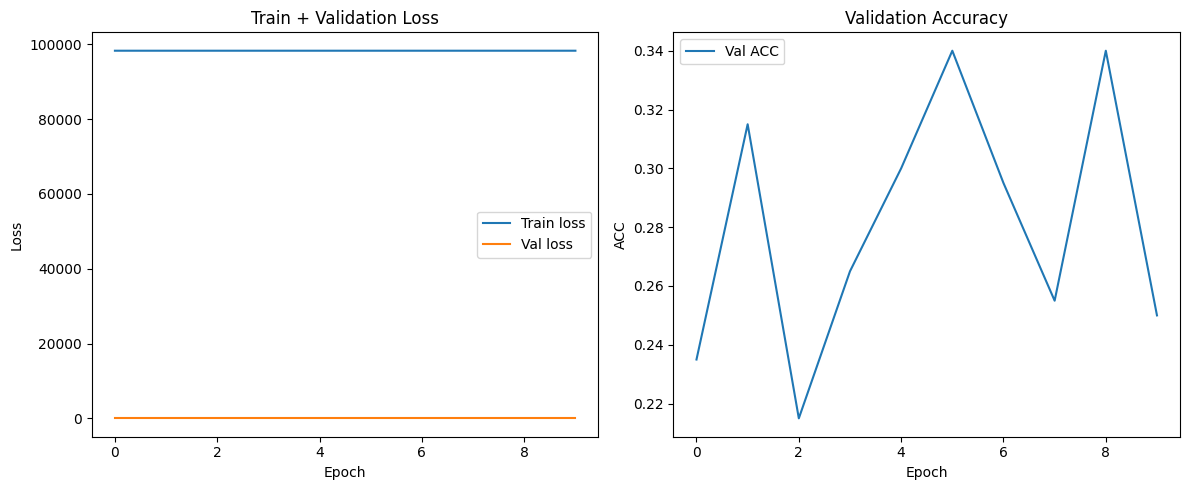

In [96]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 5))

axes[0].plot(np.arange(EPOCHS), losses_train, label="Train loss")
cpu_losses_val = [tensor.cpu() for tensor in losses_val]
axes[0].plot(np.arange(EPOCHS), cpu_losses_val, label="Val loss")
axes[0].set_title("Train + Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(np.arange(EPOCHS), accs_val, label="Val ACC")
axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("ACC")
axes[1].legend()

plt.tight_layout()
plt.show()

# Stopping point

# Save it

#### Save the weights

In [597]:
torch.save(base_model.state_dict(), getWeightsPath())

#### Save the model

In [189]:
torch.save(base_model, getModelPath())

In [ ]:
# torch_script_model = torch.jit.script(base_model)
# torch.jit.save(torch_script_model,getModelScriptPath())